Using CPU. Note: This module is much faster with a GPU.



image 1/1 d:\ml_project\anpr\notebooks\..\data\samples\test2.jpg: 352x640 1 license_plate, 198.1ms
Speed: 3.3ms preprocess, 198.1ms inference, 0.0ms postprocess per image at shape (1, 3, 352, 640)
Plate: IND RJ14CY0002
Detection Confidence: 0.95
OCR Confidence: 0.86


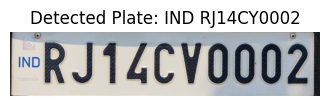

In [7]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import easyocr

# Load model
model = YOLO("../models/yolov8/best.pt")

# OCR reader
reader = easyocr.Reader(['en', 'hi'], gpu=False)

# Normalize Hindi digits → English
def normalize_text(text):
    hindi_to_eng = {
        '०':'0','१':'1','२':'2','३':'3','४':'4',
        '५':'5','६':'6','७':'7','८':'8','९':'9'
    }
    for h, e in hindi_to_eng.items():
        text = text.replace(h, e)
    return text

# Image path
image_path = "../data/samples/test2.jpg"

# Read image
img = cv2.imread(image_path)

# Run detection
results = model(image_path)

for box in results[0].boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    # Detection confidence
    det_conf = float(box.conf[0])

    crop = img[y1:y2, x1:x2]

    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    thresh = cv2.threshold(gray,150,255,cv2.THRESH_BINARY)[1]

    ocr_result = reader.readtext(thresh)

    texts = []
    confidences = []

    for res in ocr_result:
        texts.append(res[1])
        confidences.append(res[2])

    raw_text = " ".join(texts)
    text = normalize_text(raw_text)

    # Average OCR confidence
    ocr_conf = sum(confidences) / len(confidences) if confidences else 0

    print(f"Plate: {text}")
    print(f"Detection Confidence: {det_conf:.2f}")
    print(f"OCR Confidence: {ocr_conf:.2f}")

    # Show cropped plate
    plt.figure(figsize=(4,2))
    plt.imshow(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    plt.title(f"Detected Plate: {text}")
    plt.axis("off")

    # Draw on image
    label = f"{text} ({det_conf:.2f})"

    cv2.rectangle(img, (x1,y1), (x2,y2), (0,255,0), 2)
    cv2.putText(img, label, (x1, y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8,
                (0,255,0), 2)